In [1]:
# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Loading Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
import pandas as pd

# Open file picker
uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]

# Read the CSV
df = pd.read_csv(filename, encoding='latin1')
df.head()

Saving MACHINE_B_NOVEMBER_FINAL.csv to MACHINE_B_NOVEMBER_FINAL.csv


,ï»¿MACHINE_B_NOVEMBER_UPDATED,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Menu,Service,Status,Delivery,Category,Price
1,Master,Machine B,2025-11-28 13:06:11,3990009,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
2,Master,Machine B,2025-11-28 13:03:21,3989850,11,UMMIG1,Grilled Chicken Burrito Bowl,Cash,Successful,Delivery,Non vegetarian,Premium
3,Master,Machine B,2025-11-28 09:25:41,3985694,27,UMMIR7,Sweet And Sour Prawn Teriyaki Noodles,Cash,Successful,Delivery,Non vegetarian,Premium
4,Master,Machine B,2025-11-27 16:45:42,3983556,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium


In [4]:
# Clean Column Names
import pandas as pd

df.columns = [
    "GroupName",
    "Machine",
    "TransactionDate",
    "TransactionNo",
    "SlotNo",
    "ProductCode",
    "ProductName",
    "Service",
    "Status",
    "Delivery",
    "Category",
    "Price"
]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Category,Price
0,Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Menu,Service,Status,Delivery,Category,Price
1,Master,Machine B,2025-11-28 13:06:11,3990009,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
2,Master,Machine B,2025-11-28 13:03:21,3989850,11,UMMIG1,Grilled Chicken Burrito Bowl,Cash,Successful,Delivery,Non vegetarian,Premium
3,Master,Machine B,2025-11-28 09:25:41,3985694,27,UMMIR7,Sweet And Sour Prawn Teriyaki Noodles,Cash,Successful,Delivery,Non vegetarian,Premium
4,Master,Machine B,2025-11-27 16:45:42,3983556,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium


In [5]:
# Feature Engineering
import pandas as pd

df = df.iloc[1:].copy()
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="%Y-%m-%d %H:%M:%S")

df["Hour"] = df["TransactionDate"].dt.hour
df["Day"] = df["TransactionDate"].dt.day
df["Weekday"] = df["TransactionDate"].dt.weekday

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Category,Price,Hour,Day,Weekday
1,Master,Machine B,2025-11-28 13:06:11,3990009,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,13,28,4
2,Master,Machine B,2025-11-28 13:03:21,3989850,11,UMMIG1,Grilled Chicken Burrito Bowl,Cash,Successful,Delivery,Non vegetarian,Premium,13,28,4
3,Master,Machine B,2025-11-28 09:25:41,3985694,27,UMMIR7,Sweet And Sour Prawn Teriyaki Noodles,Cash,Successful,Delivery,Non vegetarian,Premium,9,28,4
4,Master,Machine B,2025-11-27 16:45:42,3983556,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,16,27,3
5,Master,Machine B,2025-11-27 14:42:22,3980068,34,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium,14,27,3


In [6]:
# Defining Target & Features
target = "ProductCode"

X = df.drop(["ProductCode", "ProductName", "TransactionDate"], axis=1)
y = df[target]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Category,Price,Hour,Day,Weekday
1,Master,Machine B,2025-11-28 13:06:11,3990009,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,13,28,4
2,Master,Machine B,2025-11-28 13:03:21,3989850,11,UMMIG1,Grilled Chicken Burrito Bowl,Cash,Successful,Delivery,Non vegetarian,Premium,13,28,4
3,Master,Machine B,2025-11-28 09:25:41,3985694,27,UMMIR7,Sweet And Sour Prawn Teriyaki Noodles,Cash,Successful,Delivery,Non vegetarian,Premium,9,28,4
4,Master,Machine B,2025-11-27 16:45:42,3983556,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,16,27,3
5,Master,Machine B,2025-11-27 14:42:22,3980068,34,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium,14,27,3


In [7]:
# Categorical Feature
import pandas as pd
X = pd.get_dummies(X, drop_first=True)
df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Category,Price,Hour,Day,Weekday
1,Master,Machine B,2025-11-28 13:06:11,3990009,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,13,28,4
2,Master,Machine B,2025-11-28 13:03:21,3989850,11,UMMIG1,Grilled Chicken Burrito Bowl,Cash,Successful,Delivery,Non vegetarian,Premium,13,28,4
3,Master,Machine B,2025-11-28 09:25:41,3985694,27,UMMIR7,Sweet And Sour Prawn Teriyaki Noodles,Cash,Successful,Delivery,Non vegetarian,Premium,9,28,4
4,Master,Machine B,2025-11-27 16:45:42,3983556,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,16,27,3
5,Master,Machine B,2025-11-27 14:42:22,3980068,34,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium,14,27,3


In [8]:
# Fill all missing values in X
X = X.fillna(0)

X.head()

,Hour,Day,Weekday,TransactionNo_3228494,TransactionNo_3229071,TransactionNo_3229587,TransactionNo_3230271,TransactionNo_3232014,TransactionNo_3234977,TransactionNo_3237565,...,SlotNo_57,SlotNo_6,SlotNo_61,SlotNo_64,SlotNo_67,Category_Non vegetarian,Category_Vegan,Category_Vegetarian,Price_Premium,Price_Standard
1,13,28,4,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
2,13,28,4,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,9,28,4,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
4,16,27,3,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
5,14,27,3,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False


In [9]:
# Updating Values for X
X = X.fillna(0)
X.head()

,Hour,Day,Weekday,TransactionNo_3228494,TransactionNo_3229071,TransactionNo_3229587,TransactionNo_3230271,TransactionNo_3232014,TransactionNo_3234977,TransactionNo_3237565,...,SlotNo_57,SlotNo_6,SlotNo_61,SlotNo_64,SlotNo_67,Category_Non vegetarian,Category_Vegan,Category_Vegetarian,Price_Premium,Price_Standard
1,13,28,4,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
2,13,28,4,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,9,28,4,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
4,16,27,3,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
5,14,27,3,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False


In [10]:
# Updating Values for Y
y = y.fillna("Unknown")
y.head()

,ProductCode
1,UMMIR4
2,UMMIG1
3,UMMIR7
4,UMMIR4
5,UMMIR10


In [11]:
# Train / Test Split
import pandas as pd
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.head()

,Hour,Day,Weekday,TransactionNo_3228494,TransactionNo_3229071,TransactionNo_3229587,TransactionNo_3230271,TransactionNo_3232014,TransactionNo_3234977,TransactionNo_3237565,...,SlotNo_57,SlotNo_6,SlotNo_61,SlotNo_64,SlotNo_67,Category_Non vegetarian,Category_Vegan,Category_Vegetarian,Price_Premium,Price_Standard
79,14,21,4,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
91,15,20,3,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
17,13,27,3,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
67,13,24,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
289,13,6,3,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [12]:
# Creating Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [13]:
# Prediction
preds = model.predict(X_test)

In [14]:
# Predicting next product likely to be sold
import pandas as pd

# Load datasets
df = pd.read_csv("MACHINE_B_NOVEMBER_FINAL.csv", encoding='latin1')

# Standardize column names as done in previous steps
df.columns = [
    "GroupName",
    "Machine",
    "TransactionDate",
    "TransactionNo",
    "SlotNo",
    "ProductCode",
    "ProductName",
    "Service",
    "Status",
    "Delivery",
    "Category",
    "Price"
]

# Drop the first row which contained the old headers, as done in previous steps
df = df.iloc[1:].copy()

# Count product frequency
product_counts = df['ProductCode'].value_counts()

# Most likely next product
next_product_code = product_counts.idxmax()
next_product_name = df[df['ProductCode'] == next_product_code].iloc[0]['ProductName']

print("Most likely next product:", next_product_name, "(", next_product_code, ")")

Most likely next product: Grilled Chicken Burrito Bowl ( UMMIG1 )


In [15]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, preds)
print("Accuracy:", accuracy)

Accuracy: 0.9154929577464789


In [16]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)
cm

array([[3, 0, 1, ..., 0, 0, 0],
       [0, 2, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 2, 0, 0],
       [0, 0, 0, ..., 0, 2, 0],
       [0, 0, 0, ..., 0, 0, 1]])

In [17]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

      UMMIB1       1.00      0.75      0.86         4
      UMMIB2       0.67      1.00      0.80         2
      UMMIB4       0.50      1.00      0.67         1
      UMMIB5       0.00      0.00      0.00         1
      UMMIB6       1.00      1.00      1.00         1
      UMMIC3       1.00      1.00      1.00         1
      UMMIF1       1.00      1.00      1.00         2
      UMMIF3       1.00      1.00      1.00         2
      UMMIG1       1.00      1.00      1.00         5
      UMMIG2       1.00      1.00      1.00         2
      UMMIJ1       1.00      1.00      1.00         2
     UMMIJ17       1.00      1.00      1.00         1
      UMMIJ2       1.00      1.00      1.00         4
      UMMIJ4       1.00      1.00      1.00         3
      UMMIJ5       1.00      1.00      1.00         2
      UMMIM1       0.00      0.00      0.00         0
     UMMIM10       1.00      1.00      1.00         2
      UMMIM3       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

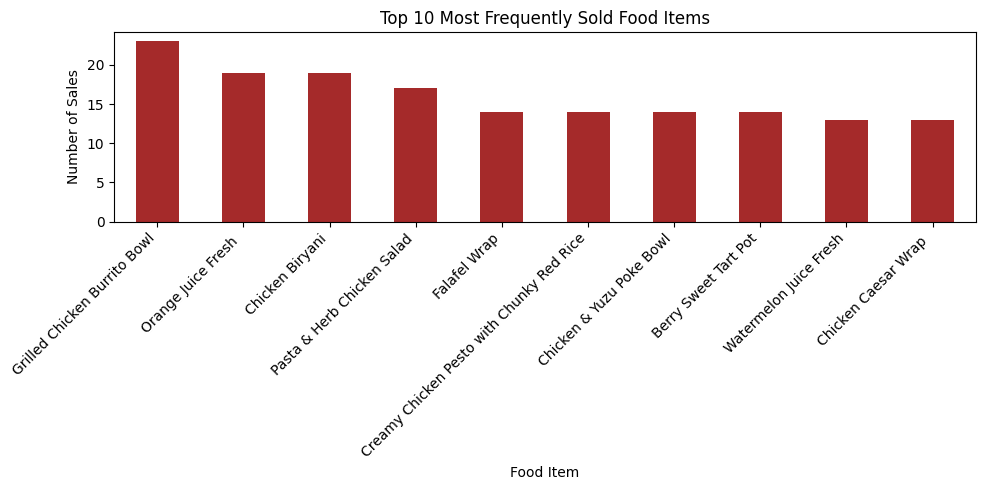

In [27]:
# Food Item Frequency Bar Chart
import matplotlib.pyplot as plt

food_counts = df['Menu'].value_counts().head(10)

plt.figure(figsize=(10,5))
food_counts.plot(kind='bar', color='brown')

plt.title("Top 10 Most Frequently Sold Food Items")
plt.xlabel("Food Item")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



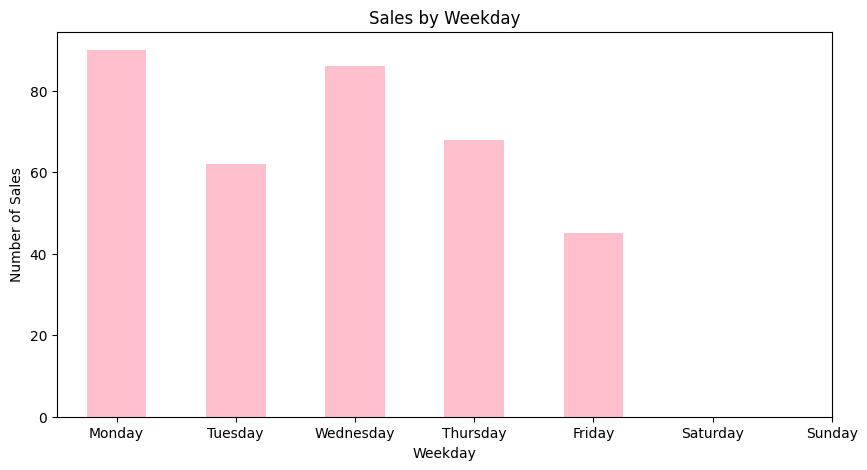

In [28]:
# Sales By Weekday
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

weekday_counts = df['TransactionDate'].dt.weekday.value_counts().sort_index()

weekday_labels = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10,5))
weekday_counts.plot(kind='bar', color='pink')

plt.title("Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Sales")
plt.xticks(ticks=range(7), labels=weekday_labels, rotation=0)
plt.show()
